## Titanic Survival Prediction — EDA & Analysis

This notebook contains my full exploratory analysis of the Titanic dataset.
The clean production version is in train_model.py

In [46]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [47]:
train = pd.read_csv('train.csv')
"test  = pd.read_csv('test.csv')"

print(train.shape)  # (891, 12)
"print(test.shape)   # (418, 11)"
train.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [48]:
train.info()
train.describe()
train.isnull().sum()
train.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,0
PassengerId,891
Survived,2
Pclass,3
Name,891
Sex,2
Age,88
SibSp,7
Parch,7
Ticket,681
Fare,248


In [49]:
train=train.drop(columns=['Ticket'])

In [50]:
train=train.drop(columns=['Parch','PassengerId'])

In [51]:
train=train.drop(columns=['Cabin','Name'])

In [52]:
train=train.dropna()

In [53]:
train['Age'].fillna(train['Age'].median(), inplace=True)

/tmp/ipykernel_1591/486169235.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Age'].fillna(train['Age'].median(), inplace=True)


In [54]:
train.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Fare,0
Embarked,0


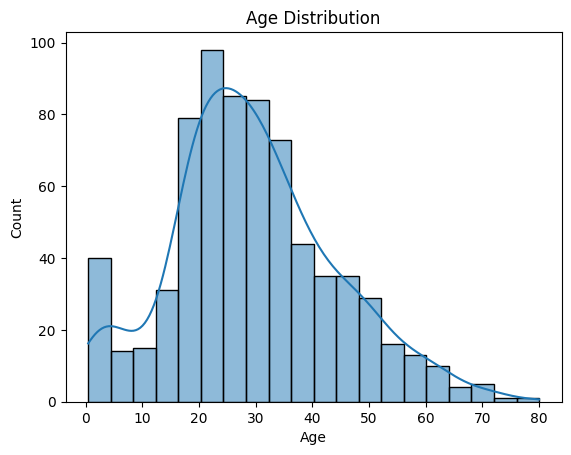

In [55]:
sns.histplot(train['Age'], kde=True)
plt.title('Age Distribution')
plt.show()

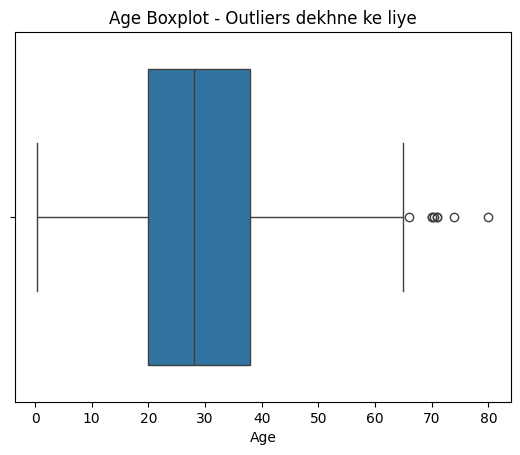

In [56]:
sns.boxplot(x=train['Age'])
plt.title('Age Boxplot - Outliers dekhne ke liye')
plt.show()

In [57]:
train.describe()

,Survived,Pclass,Age,SibSp,Fare
count,712.000000,712.000000,712.000000,712.000000,712.000000
mean,0.404494,2.240169,29.642093,0.514045,34.567251
std,0.491139,0.836854,14.492933,0.930692,52.938648
min,0.000000,1.000000,0.420000,0.000000,0.000000
25%,0.000000,1.000000,20.000000,0.000000,8.050000
50%,0.000000,2.000000,28.000000,0.000000,15.645850
75%,1.000000,3.000000,38.000000,1.000000,33.000000
max,1.000000,3.000000,80.000000,5.000000,512.329200


##Use to detect Outlier


In [58]:
Q1=train['Age'].quantile(0.25)
Q3=train['Age'].quantile(0.75)
IQR=Q3-Q1
print(Q1,Q3,IQR)

20.0 38.0 18.0


In [59]:
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

In [60]:
outliers = train[(train['Age'] < lower) | (train['Age'] > upper)]
print(f"Outliers count: {len(outliers)}")

Outliers count: 8


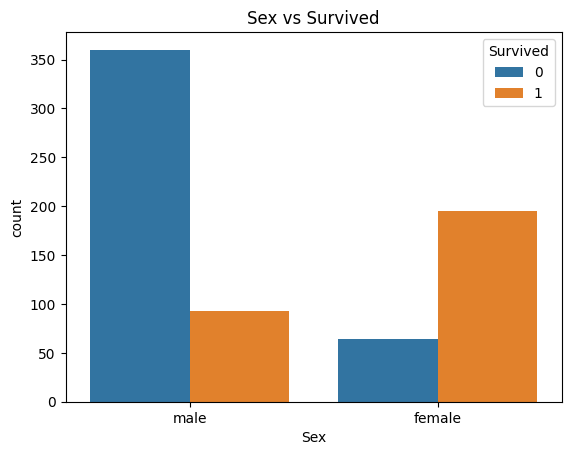

In [61]:
sns.countplot(x='Sex', hue='Survived', data=train)
plt.title('Sex vs Survived')
plt.show()

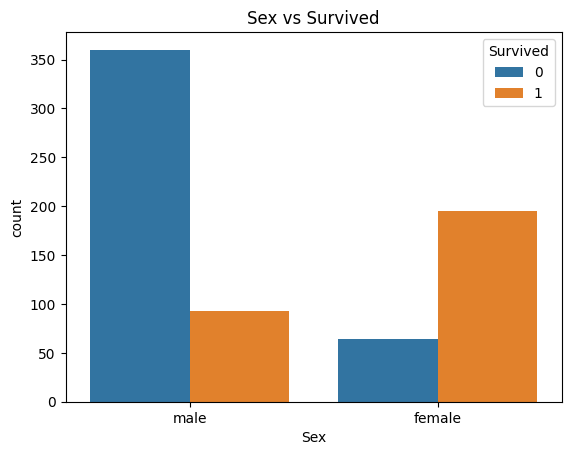

In [62]:
sns.countplot(x='Sex', hue='Survived', data=train)
plt.title('Sex vs Survived')
plt.show()

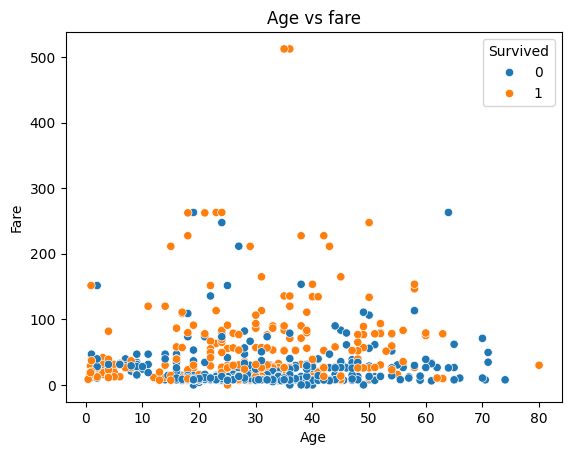

In [63]:
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=train)
plt.title('Age vs fare')
plt.show()

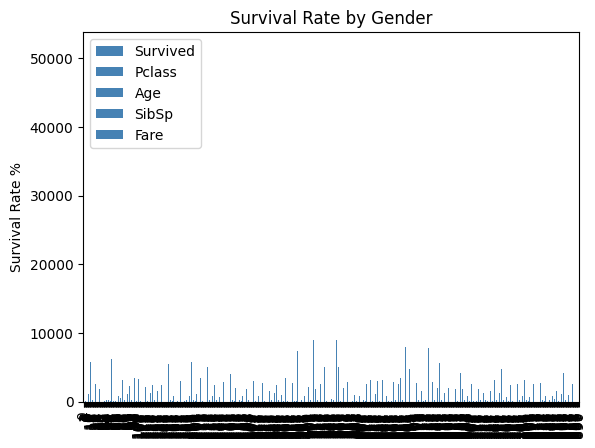

In [64]:
train.groupby('Sex')['Survived'].mean()
train.mul(100).plot(kind='bar', color='steelblue')
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate %')
plt.show()

In [65]:
print(train['Sex'].unique())
print(train['Sex'].dtype)

['male' 'female']
object


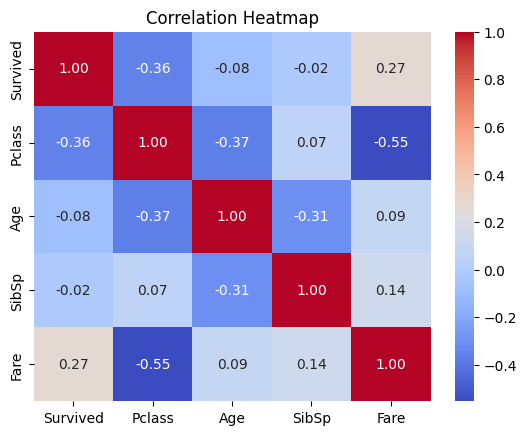

In [66]:
sns.heatmap(train.corr(numeric_only=True),
  annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

Sex
female    75.289575
male      20.529801
Name: Survived, dtype: float64


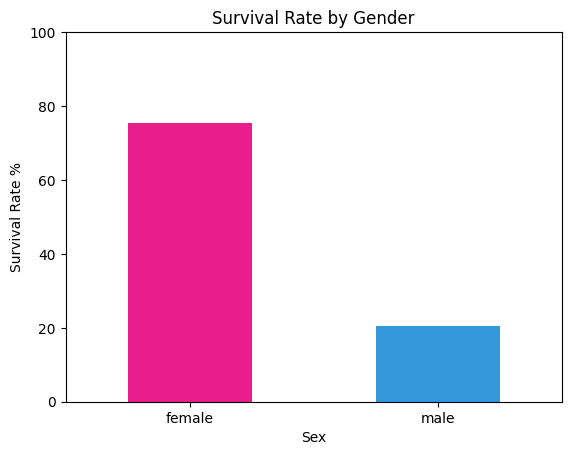

In [67]:
survival_rate = train.groupby('Sex')['Survived'].mean() * 100
print(survival_rate)

survival_rate.plot(kind='bar',
                   color=['#e91e8c', '#3498db'])
plt.xticks(rotation=0)
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate %')
plt.ylim(0, 100)
plt.show()

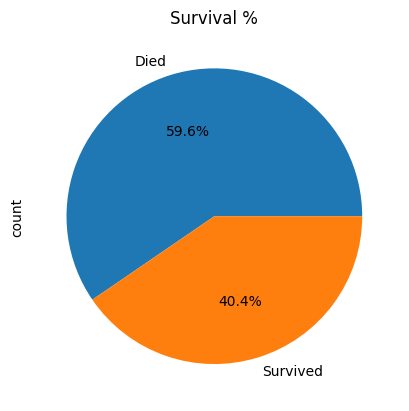

In [68]:
train['Survived'].value_counts().plot(
  kind='pie', autopct='%1.1f%%',
  labels=['Died','Survived'])
plt.title('Survival %')
plt.show()

In [69]:
train[['Fare','Pclass','Survived']].corr()

,Fare,Pclass,Survived
Fare,1.000000,-0.552893,0.266100
Pclass,-0.552893,1.000000,-0.356462
Survived,0.266100,-0.356462,1.000000


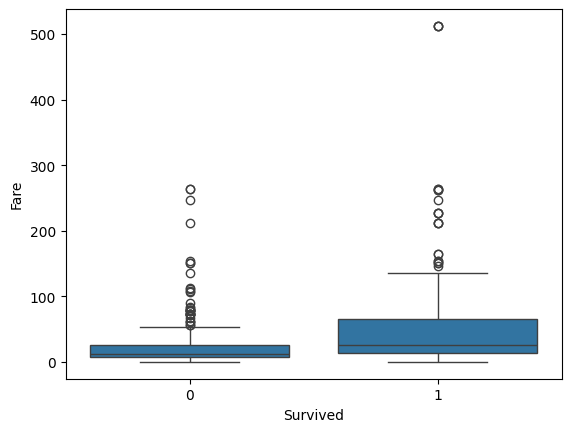

In [70]:
sns.boxplot(x='Survived', y='Fare', data=train)
plt.show()

In [71]:
train[['Sex','Pclass','Fare','Survived']].corr(numeric_only=True)

,Pclass,Fare,Survived
Pclass,1.000000,-0.552893,-0.356462
Fare,-0.552893,1.000000,0.266100
Survived,-0.356462,0.266100,1.000000


In [72]:
train.groupby(['Pclass','Age'])['Survived'].mean()

Pclass  Age  
1       0.92     1.0
        2.00     0.0
        4.00     1.0
        11.00    1.0
        14.00    1.0
                ... 
3       61.00    0.0
        63.00    1.0
        65.00    0.0
        70.50    0.0
        74.00    0.0
Name: Survived, Length: 182, dtype: float64

<Axes: xlabel='Pclass', ylabel='Survived'>

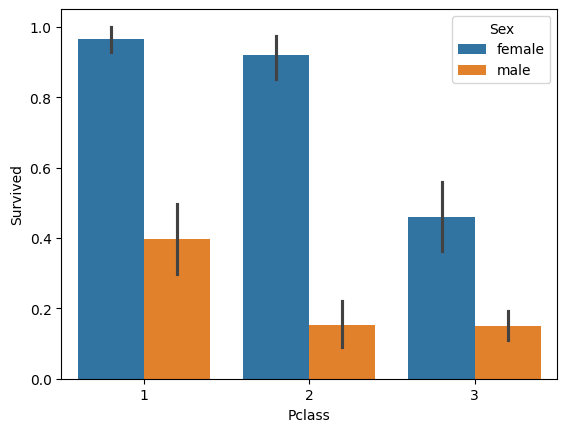

In [73]:
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=train)

<Axes: xlabel='Pclass', ylabel='Survived'>

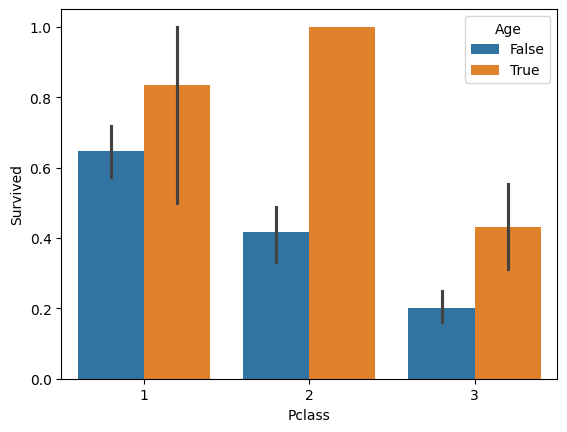

In [74]:
sns.barplot(x='Pclass', y='Survived', hue=(train['Age']<16), data=train)

In [75]:
train['IsChild'] = train['Age'] < 16

In [76]:
train

,Survived,Pclass,Sex,Age,SibSp,Fare,Embarked,IsChild
0,0,3,male,22.0,1,7.2500,S,False
1,1,1,female,38.0,1,71.2833,C,False
2,1,3,female,26.0,0,7.9250,S,False
3,1,1,female,35.0,1,53.1000,S,False
4,0,3,male,35.0,0,8.0500,S,False
...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,29.1250,Q,False
886,0,2,male,27.0,0,13.0000,S,False
887,1,1,female,19.0,0,30.0000,S,False
889,1,1,male,26.0,0,30.0000,C,False


In [77]:
train['IsChild'].value_counts()

,count
IsChild,
False,629
True,83


In [78]:
train.groupby('IsChild')['Survived'].mean()

,Survived
IsChild,
False,0.379968
True,0.590361


In [79]:
train['Priority'] = ((train['Sex'] == 'female') | (train['IsChild']))

In [80]:
train.groupby('Priority')['Survived'].mean()

,Survived
Priority,
False,0.174334
True,0.722408


In [81]:
train['Sex'] = train['Sex'].map({'male':0, 'female':1})
train['Embarked'] = train['Embarked'].map({'S':0, 'C':1, 'Q':2})

In [82]:
X = train[['Pclass','Sex','Age','Fare','IsChild','Priority']]
y = train['Survived']

In [83]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [84]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [85]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [86]:
y_pred = model.predict(X_test_scaled)

In [87]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8181818181818182
